In [8]:
from google.colab import files
uploaded = files.upload()

Saving True.csv to True.csv
Saving Fake.csv to Fake.csv


In [9]:
import pandas as pd

# Load the datasets
real_news = pd.read_csv('True.csv')

# Printing head and tail
print(real_news)

# Print length => rows
print("Length (rows):", len(real_news))

                                                   title  \
0      As U.S. budget fight looms, Republicans flip t...   
1      U.S. military to accept transgender recruits o...   
2      Senior U.S. Republican senator: 'Let Mr. Muell...   
3      FBI Russia probe helped by Australian diplomat...   
4      Trump wants Postal Service to charge 'much mor...   
...                                                  ...   
21412  'Fully committed' NATO backs new U.S. approach...   
21413  LexisNexis withdrew two products from Chinese ...   
21414  Minsk cultural hub becomes haven from authorities   
21415  Vatican upbeat on possibility of Pope Francis ...   
21416  Indonesia to buy $1.14 billion worth of Russia...   

                                                    text       subject  \
0      WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1      WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2      WASHINGTON (Reuters) - The special counsel inv... 

In [10]:
import pandas as pd

# Load the datasets
fake_news = pd.read_csv('Fake.csv')

# Printing head and tail
print(fake_news)

# Print length => rows
print("Length (rows):", len(fake_news))


                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
23476  McPain: John McCain Furious That Iran Treated ...   
23477  JUSTICE? Yahoo Settles E-mail Privacy Class-ac...   
23478  Sunnistan: US and Allied ‘Safe Zone’ Plan to T...   
23479  How to Blow $700 Million: Al Jazeera America F...   
23480  10 U.S. Navy Sailors Held by Iranian Military ...   

                                                    text      subject  \
0      Donald Trump just couldn t wish all Americans ...         News   
1      House Intelligence Committee Chairman Devin Nu...         News   
2      On Friday, it was revealed that former Milwauk...    

In [11]:
fake_news = pd.read_csv('Fake.csv')
real_news = pd.read_csv('True.csv')

# Combine the datasets and shuffle
fake_news['label'] = 0    # adds a column
real_news['label'] = 1

data = pd.concat([fake_news, real_news]).sample(frac=1.0)   # frac 1.0 => returns all the data (rows)

# Write the combined data to a new CSV file
data.to_csv('Combined.csv', index=False)

print("Data loaded successfully and combined CSV generated!")

data

Data loaded successfully and combined CSV generated!


,title,text,subject,date,label
10506,BROKE City of Chicago Spends Taxpayer Money St...,The Windy City is under fire for turning publi...,politics,"Jun 30, 2017",0
1463,Ann Coulter Is Super Pissed That Trump Is A D...,Donald Trump s number one fan still believes i...,News,"May 15, 2017",0
7275,Thousands of students carry protests against T...,SAN FRANCISCO (Reuters) - Demonstrations prote...,politicsNews,"November 15, 2016",1
11620,British PM May says Russia trying to weaponize...,WARSAW (Reuters) - British Prime Minister Ther...,worldnews,"December 21, 2017",1
13164,U.S. defense chief urges Pakistan to redouble ...,ISLAMABAD (Reuters) - U.S. Defense Secretary J...,worldnews,"December 4, 2017",1
...,...,...,...,...,...
18701,WATCH TUCKER CARLSON’S Heated Debate With Delu...,"Tucker Carlson interviews Jose Antonio Vargas,...",left-news,"May 3, 2017",0
10934,Factbox: What will be in Obama's final budget ...,(Reuters) - President Barack Obama is set on T...,politicsNews,"February 6, 2016",1
21757,OUTRAGEOUS VIDEOS: WATCH THE LEFTISTS BLAME TH...,The point is Alan Dershowitz made this absurd...,left-news,"May 9, 2015",0
6360,WATCH: CNN Host Destroys Trump Campaign Manag...,Despite the fact that Donald Trump has admitte...,News,"May 15, 2016",0


In [12]:
import re
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def preprocess_text(text):
    # Replace characters that are not between a to z or A to Z with whitespace
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Convert all characters into lowercase
    text = text.lower()

    # Remove inflectional morphemes like "ed", "est", "s", and "ing" from their token stem
    text = [stemmer.stem(word) for word in text.split()]

    # Join the processed words back into a single string
    text = ' '.join(text)

    return text

In [15]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [19]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [20]:
import torch
from transformers import BertForSequenceClassification

# Load model
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU/CPU
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [21]:
!pip install transformers torch scikit-learn

import pandas as pd
import torch
import re
from torch.utils.data import TensorDataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ================================
# 2. Device (GPU / CPU)
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ================================
# 3. Load Dataset
# ================================
data = pd.read_csv("Combined.csv")

print("Dataset Shape:", data.shape)
print(data.head())

# ================================
# 4. Text Preprocessing
# ================================
def preprocess_text(text):

    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)

    return text

data["title_preprocessed"] = data["title"].apply(preprocess_text)

# ================================
# 5. Train / Validation / Test Split
# ================================
train_ratio = 0.64
val_ratio = 0.16
test_ratio = 0.20

train_data = data.sample(frac=train_ratio, random_state=42)
remaining = data.drop(train_data.index)

val_data = remaining.sample(frac=val_ratio/(val_ratio+test_ratio), random_state=42)
test_data = remaining.drop(val_data.index)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

# ================================
# 6. Load BERT Tokenizer
# ================================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# ================================
# 7. Tokenization
# ================================
train_inputs = tokenizer(
    list(train_data["title_preprocessed"]),
    truncation=True,
    padding="max_length",
    max_length=42,
    return_tensors="pt"
)

val_inputs = tokenizer(
    list(val_data["title_preprocessed"]),
    truncation=True,
    padding="max_length",
    max_length=42,
    return_tensors="pt"
)

test_inputs = tokenizer(
    list(test_data["title_preprocessed"]),
    truncation=True,
    padding="max_length",
    max_length=42,
    return_tensors="pt"
)

# ================================
# 8. Labels → Torch Tensor
# ================================
train_labels = torch.tensor(train_data["label"].values, dtype=torch.long)
val_labels = torch.tensor(val_data["label"].values, dtype=torch.long)
test_labels = torch.tensor(test_data["label"].values, dtype=torch.long)

# ================================
# 9. Create Dataset
# ================================
train_dataset = TensorDataset(
    train_inputs["input_ids"],
    train_inputs["attention_mask"],
    train_labels
)

val_dataset = TensorDataset(
    val_inputs["input_ids"],
    val_inputs["attention_mask"],
    val_labels
)

test_dataset = TensorDataset(
    test_inputs["input_ids"],
    test_inputs["attention_mask"],
    test_labels
)

# ================================
# 10. DataLoader
# ================================
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# ================================
# 11. Load BERT Model
# ================================
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.to(device)

# ================================
# 12. Optimizer
# ================================
optimizer = AdamW(model.parameters(), lr=2e-5)

Using device: cuda
Dataset Shape: (44898, 5)
                                               title  \
0  BROKE City of Chicago Spends Taxpayer Money St...   
1   Ann Coulter Is Super Pissed That Trump Is A D...   
2  Thousands of students carry protests against T...   
3  British PM May says Russia trying to weaponize...   
4  U.S. defense chief urges Pakistan to redouble ...   

                                                text       subject  \
0  The Windy City is under fire for turning publi...      politics   
1  Donald Trump s number one fan still believes i...          News   
2  SAN FRANCISCO (Reuters) - Demonstrations prote...  politicsNews   
3  WARSAW (Reuters) - British Prime Minister Ther...     worldnews   
4  ISLAMABAD (Reuters) - U.S. Defense Secretary J...     worldnews   

                 date  label  
0        Jun 30, 2017      0  
1        May 15, 2017      0  
2  November 15, 2016       1  
3  December 21, 2017       1  
4   December 4, 2017       1  
Train size:

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
epochs = 3

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

KeyboardInterrupt: 

In [25]:
epochs = 3

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

Epoch: 1 Loss: 0.008692169018698837
Epoch: 2 Loss: 0.007747332870686722
Epoch: 3 Loss: 0.007071405961294797


In [26]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [27]:
accuracy = accuracy_score(true_labels, predictions)

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(true_labels, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, predictions))

# ================================
# 16. Save Model
# ================================
model.save_pretrained("bert_fake_news_model")
tokenizer.save_pretrained("bert_fake_news_model")

print("\nModel Saved Successfully!")


Accuracy: 0.9773916917251364

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4655
           1       0.97      0.99      0.98      4324

    accuracy                           0.98      8979
   macro avg       0.98      0.98      0.98      8979
weighted avg       0.98      0.98      0.98      8979


Confusion Matrix:
[[4508  147]
 [  56 4268]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model Saved Successfully!


In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [29]:
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9773916917251364
Precision: 0.9667044167610419
Recall: 0.9870490286771508
F1 Score: 0.9767707975740931


In [30]:
cm = confusion_matrix(true_labels, predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4508  147]
 [  56 4268]]


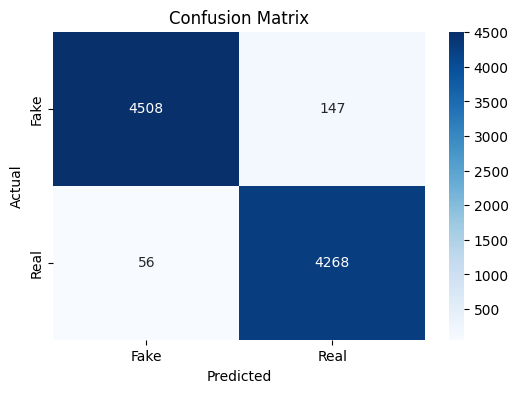

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
misclassified = []

model.eval()

with torch.no_grad():

    for i, batch in enumerate(test_loader):

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        for j in range(len(labels)):
            if preds[j] != labels[j]:
                misclassified.append((preds[j].item(), labels[j].item()))

In [33]:
print("Total Misclassified Samples:", len(misclassified))

for i in range(5):
    print("Predicted:", misclassified[i][0],
          "Actual:", misclassified[i][1])

Total Misclassified Samples: 203
Predicted: 1 Actual: 0
Predicted: 1 Actual: 0
Predicted: 0 Actual: 1
Predicted: 1 Actual: 0
Predicted: 0 Actual: 1


In [35]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [36]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

In [37]:
epochs = 3

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    print("Epoch:", epoch+1, "Loss:", total_loss/len(train_loader))

Epoch: 1 Loss: 0.0036866002864086086
Epoch: 2 Loss: 0.0002666442049390542
Epoch: 3 Loss: 0.0017550073290225807


In [38]:
!pip install gradio

In [39]:
def predict_news(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=1).item()

    if predicted_class == 1:
        return "Real News"
    else:
        return "Fake News"

In [40]:
import gradio as gr

interface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=3, placeholder="Enter news headline here..."),
    outputs="text",
    title="Fake News Detection using BERT",
    description="Enter a news headline and the model will predict whether it is Fake or Real."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2b01b088586f87e1c0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
